In [ ]:
# =============================================================
# Adversarial Attacks Series — Note 02
# Walls, Shields, and Illusions: Adversarial Training vs. PGD
# =============================================================
#
# Series:  Humble Model / Adversarial Awareness
# Dataset: MNIST
# Model:   Small CNN (same as Note 01)
#
# Notebook structure:
#   Part A: Imports and Setup
#   Part B: Dataset Loading
#   Part C: Model Architecture
#   Part D: Baseline Model Training (or Load)
#   Part E: Attack Functions (FGSM, PGD)
#   Part F: Baseline Model Evaluation (FGSM, PGD)
#   Part G: Adversarial Training with FGSM
#   Part H: Adversarial Training with PGD
#   Part I: Comparative Evaluation
#   Part J: Trade-off Visualization
#   Part K: Summary and Outputs
#   Part L: Defensive Distillation — third experimental wall
#   Part M: Confidence experiment: PGD-trained model vs. the 22 images that fooled the undefended model in Essay 2
#   Part N: Standalone baseline epsilon-curve figure (Figure 1: for Section III, isolated from the 3-model comparison)
# =============================================================

In [1]:
# ─────────────────────────────────────────────────────────────
# Part A: Imports and Setup
# ─────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
# ─────────────────────────────────────────────────────────────
# Part B: Dataset Loading (MNIST)
# ─────────────────────────────────────────────────────────────

# MNIST normalization constants
MEAN, STD = (0.1307,), (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Training samples: 60,000
Test samples: 10,000


In [3]:
#──────────────────────────────────────────────────────
# Part C: Model Architecture (Same as Note 01)
# ─────────────────────────────────────────────────────────────

class CNN(nn.Module):
    """Small CNN for MNIST — same architecture as Essay #2"""
    
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.fc1: nn.Linear | None = None
        self.fc2 = nn.Linear(128, num_classes)
        self.flattened_size: int | None = None

    def reset_for_input_size(self, input_size: int) -> None:
        """Compute fc1 input dimension from a dry-run on a dummy tensor."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            x = F.max_pool2d(F.relu(self.conv1(dummy)), 2)
            x = F.max_pool2d(F.relu(self.conv2(x)), 2)
            self.flattened_size = x.view(1, -1).size(1)
            self.fc1 = nn.Linear(self.flattened_size, 128)
        print(f"🔄 Model initialised for {input_size}×{input_size} → flattened: {self.flattened_size}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.fc1 is None:
            raise RuntimeError("Call reset_for_input_size() before forward().")
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
# ─────────────────────────────────────────────────────────────
# Part D: Attack Functions
# ─────────────────────────────────────────────────────────────

def fgsm_attack(image, epsilon, data_grad):
    """Fast Gradient Sign Method (single step)"""
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def pgd_attack(model, images, labels, epsilon, step_size, num_steps, random_start=True):
    """
    Projected Gradient Descent (multi-step)
    
    Args:
        model: Target model
        images: Clean images (normalized [0,1])
        labels: True labels
        epsilon: Maximum perturbation (L∞)
        step_size: Step size per iteration
        num_steps: Number of PGD steps
        random_start: If True, start from random perturbation within epsilon
    
    Returns:
        Adversarial images
    """
    model.eval()
    images = images.clone().detach().to(DEVICE)
    labels = labels.clone().detach().to(DEVICE)
    
    # Start from random perturbation if enabled
    if random_start:
        delta = torch.zeros_like(images).uniform_(-epsilon, epsilon)
        delta = torch.clamp(delta, -epsilon, epsilon)
        adv_images = torch.clamp(images + delta, 0, 1).detach()
    else:
        adv_images = images.clone().detach()
    
    for _ in range(num_steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()
        
        # Update perturbation
        grad_sign = adv_images.grad.data.sign()
        adv_images = adv_images + step_size * grad_sign
        # Project back into epsilon ball
        eta = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images = torch.clamp(images + eta, 0, 1).detach()
    
    return adv_images

def evaluate_accuracy(model, data_loader, attack_type=None, attack_params=None):
    """
    Evaluate model accuracy on clean or adversarial data
    
    Args:
        model: PyTorch model
        data_loader: DataLoader for test set
        attack_type: None (clean), 'fgsm', or 'pgd'
        attack_params: dict with epsilon, step_size, num_steps for attacks
    
    Returns:
        accuracy (float), predictions (list), confidences (list)
    """
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_confidences = []
    
    for images, labels in data_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        if attack_type == 'fgsm':
            # Compute gradients for FGSM
            images.requires_grad = True
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            model.zero_grad()
            loss.backward()
            grad = images.grad.data
            images = fgsm_attack(images, attack_params['epsilon'], grad)
            outputs = model(images)
        elif attack_type == 'pgd':
            images = pgd_attack(model, images, labels, 
                                epsilon=attack_params['epsilon'],
                                step_size=attack_params['step_size'],
                                num_steps=attack_params['num_steps'])
            outputs = model(images)
        else:
            outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_confidences.extend(probs.max(dim=1)[0].cpu().detach().numpy())
    
    accuracy = 100 * correct / total
    return accuracy, all_preds, all_confidences

In [26]:
# ─────────────────────────────────────────────────────────────
# Part E: Baseline Model Training (or Load)
# ─────────────────────────────────────────────────────────────

def train_model(model, train_loader, epochs=10, adversarial_training=False, 
                attack_type=None, attack_params=None):
    """
    Train model with optional adversarial training
    
    Args:
        model: PyTorch model
        train_loader: DataLoader for training
        epochs: Number of epochs
        adversarial_training: If True, use adversarial examples in training
        attack_type: 'fgsm' or 'pgd' for adversarial training
        attack_params: dict with attack parameters
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            if adversarial_training and attack_type == 'fgsm':
                # Generate FGSM adversarial examples for training
                images.requires_grad = True
                outputs = model(images)
                loss = criterion(outputs, labels)
                model.zero_grad()
                loss.backward()
                grad = images.grad.data
                adv_images = fgsm_attack(images, attack_params['epsilon'], grad)
                images = adv_images.detach()
            elif adversarial_training and attack_type == 'pgd':
                # Generate PGD adversarial examples for training
                images = pgd_attack(model, images, labels,
                                    epsilon=attack_params['epsilon'],
                                    step_size=attack_params['step_size'],
                                    num_steps=attack_params['num_steps'])
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        print(f"📊 Epoch {epoch} — avg loss: {avg_loss:.4f}")
    
    return model

# Train or load baseline model
print("\n" + "="*55)
print("📦 Baseline Model")
print("="*55)

baseline_model = CNN().to(DEVICE)
baseline_model.reset_for_input_size(28)

# Check if checkpoint exists
if os.path.exists('checkpoint_baseline.pth'):
    checkpoint = torch.load('checkpoint_baseline.pth', map_location=DEVICE)
    baseline_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded baseline model from checkpoint")
else:
    print("🆕 Training baseline model from scratch...")
    baseline_model = train_model(baseline_model, train_loader, epochs=10)
    torch.save({'model_state_dict': baseline_model.state_dict()}, 'checkpoint_baseline.pth')
    print("💾 Saved baseline model checkpoint")

# Evaluate baseline clean accuracy
clean_acc, _, _ = evaluate_accuracy(baseline_model, test_loader)
print(f"\n📈 Baseline clean test accuracy: {clean_acc:.2f}%")


📦 Baseline Model
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded baseline model from checkpoint

📈 Baseline clean test accuracy: 99.00%


In [27]:
# ─────────────────────────────────────────────────────────────
# Part F: Baseline Model Under Attack
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("⚔️ Baseline Model Under Attack")
print("="*55)

# FIX: Extract only the accuracy value from the tuple
clean_acc, _, _ = evaluate_accuracy(baseline_model, test_loader)

# FGSM attack
fgsm_params = {'epsilon': 0.3}
fgsm_acc, _, _ = evaluate_accuracy(baseline_model, test_loader, 
                                    attack_type='fgsm', attack_params=fgsm_params)
print(f"Baseline + FGSM (ε=0.3) accuracy: {fgsm_acc:.2f}%")


# PGD attack
pgd_params = {'epsilon': 0.3, 'step_size': 0.01, 'num_steps': 40}
pgd_acc, _, _ = evaluate_accuracy(baseline_model, test_loader,
                                    attack_type='pgd', attack_params=pgd_params)
print(f"Baseline + PGD (ε=0.3, steps=40) accuracy: {pgd_acc:.2f}%")



⚔️ Baseline Model Under Attack
Baseline + FGSM (ε=0.3) accuracy: 96.60%
Baseline + PGD (ε=0.3, steps=40) accuracy: 95.61%


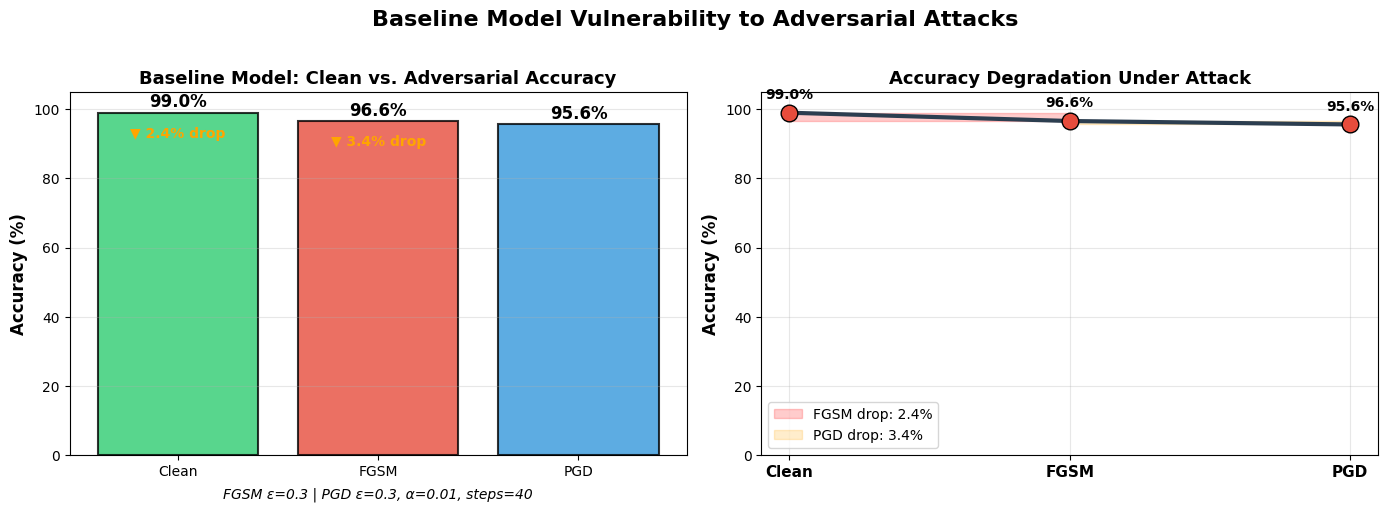

📊 Figure saved as 'baseline_attack_performance.png'

📊 Performance Summary
Attack Type     Accuracy     Degradation    
-------------------------------------------------------
Clean            99.00%                
FGSM (ε=0.3)     96.60%   2.40% drop
PGD (ε=0.3)      95.61%   3.39% drop


In [28]:
# ─────────────────────────────────────────────────────────────
# Visualization: Baseline Model Under Attack
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Get clean accuracy (assuming you have it from earlier)
# If not, compute it first
try:
    clean_acc  # Use existing variable
except NameError:
    clean_acc_baseline, _, _ = evaluate_accuracy(baseline_model, test_loader)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ─── Plot 1: Bar chart comparison ───
attack_types = ['Clean', 'FGSM', 'PGD']
accuracies = [clean_acc, fgsm_acc, pgd_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']  # Green, Red, Blue

bars = ax1.bar(attack_types, accuracies, color=colors, 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add attack parameters as annotations
ax1.text(0.5, -0.12, f'FGSM ε=0.3 | PGD ε=0.3, α=0.01, steps=40', 
         transform=ax1.transAxes, ha='center', fontsize=10, style='italic')

ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Baseline Model: Clean vs. Adversarial Accuracy', 
              fontsize=13, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3, axis='y')

# Add degradation percentages
degradation_fgsm = clean_acc - fgsm_acc
degradation_pgd = clean_acc - pgd_acc

for i, (attack, deg) in enumerate(zip(['FGSM', 'PGD'], [degradation_fgsm, degradation_pgd])):
    color = 'darkred' if deg > 20 else 'orange'
    ax1.text(i, accuracies[i] - 8, f'▼ {deg:.1f}% drop', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

# ─── Plot 2: Line plot showing accuracy degradation ───
attack_names = ['Clean', 'FGSM', 'PGD']
x_pos = np.arange(len(attack_names))

ax2.plot(x_pos, accuracies, marker='o', markersize=12, linewidth=3, 
         color='#2c3e50', markerfacecolor='#e74c3c', markeredgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(attack_names, fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Degradation Under Attack', 
              fontsize=13, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

# Add value labels on points
for i, acc in enumerate(accuracies):
    ax2.annotate(f'{acc:.1f}%', (x_pos[i], acc), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold')

# Shade the degradation area
ax2.fill_between(x_pos[0:2], accuracies[0], accuracies[1], 
                  alpha=0.2, color='red', label=f'FGSM drop: {degradation_fgsm:.1f}%')
ax2.fill_between(x_pos[1:3], accuracies[1], accuracies[2], 
                  alpha=0.2, color='orange', label=f'PGD drop: {degradation_pgd:.1f}%')
ax2.legend(loc='lower left', fontsize=10)

plt.suptitle('Baseline Model Vulnerability to Adversarial Attacks', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('baseline_attack_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Figure saved as 'baseline_attack_performance.png'")

# ─── Additional: Summary table visualization ───
print("\n" + "="*55)
print("📊 Performance Summary")
print("="*55)
print(f"{'Attack Type':<15} {'Accuracy':<12} {'Degradation':<15}")
print("-"*55)
print(f"{'Clean':<15} {clean_acc:>6.2f}% {'':<15}")
print(f"{'FGSM (ε=0.3)':<15} {fgsm_acc:>6.2f}% {degradation_fgsm:>6.2f}% drop")
print(f"{'PGD (ε=0.3)':<15} {pgd_acc:>6.2f}% {degradation_pgd:>6.2f}% drop")
print("="*55)

In [8]:
# ─────────────────────────────────────────────────────────────
# Part G: Adversarial Training with FGSM
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("🏗️ Adversarial Training with FGSM")
print("="*55)

fgsm_trained_model = CNN().to(DEVICE)
fgsm_trained_model.reset_for_input_size(28)

if os.path.exists('checkpoint_fgsm_trained.pth'):
    checkpoint = torch.load('checkpoint_fgsm_trained.pth', map_location=DEVICE)
    fgsm_trained_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded FGSM-trained model from checkpoint")
else:
    print("🆕 Training FGSM-robust model...")
    fgsm_params_train = {'epsilon': 0.3}
    fgsm_trained_model = train_model(fgsm_trained_model, train_loader, epochs=10,
                                      adversarial_training=True, attack_type='fgsm',
                                      attack_params=fgsm_params_train)
    torch.save({'model_state_dict': fgsm_trained_model.state_dict()}, 'checkpoint_fgsm_trained.pth')
    print("💾 Saved FGSM-trained model checkpoint")

# Evaluate FGSM-trained model
clean_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader)
fgsm_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader,
                                          attack_type='fgsm', attack_params=fgsm_params)
pgd_acc_fgsm, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader,
                                         attack_type='pgd', attack_params=pgd_params)

print(f"\n📊 FGSM-trained model:")
print(f"   Clean accuracy: {clean_acc_fgsm:.2f}%")
print(f"   Under FGSM (ε=0.3): {fgsm_acc_fgsm:.2f}%")
print(f"   Under PGD (ε=0.3): {pgd_acc_fgsm:.2f}%")


🏗️ Adversarial Training with FGSM
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded FGSM-trained model from checkpoint

📊 FGSM-trained model:
   Clean accuracy: 99.08%
   Under FGSM (ε=0.3): 97.97%
   Under PGD (ε=0.3): 97.65%


🔄 Model initialised for 28×28 → flattened: 800


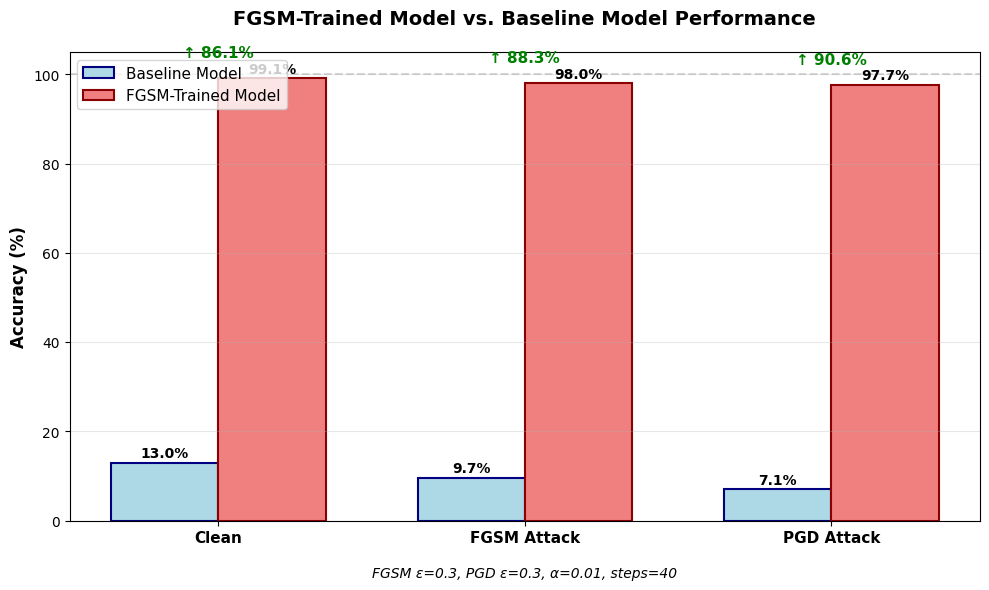

📊 Figure saved as 'fgsm_training_comparison.png'


In [ ]:
# ─────────────────────────────────────────────────────────────
# Visualization: FGSM-trained model vs. Baseline
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np


baseline_clean_acc = clean_acc
baseline_fgsm_acc = fgsm_acc
baseline_pgd_acc = pgd_acc


# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Define the groups and values
models = ['Clean', 'FGSM Attack', 'PGD Attack']
baseline_accuracies = [baseline_clean_acc, baseline_fgsm_acc, baseline_pgd_acc]
fgsm_trained_accuracies = [clean_acc_fgsm, fgsm_acc_fgsm, pgd_acc_fgsm]

# Set up bar positions
x = np.arange(len(models))
width = 0.35

# Create bars with different colors
bars1 = ax.bar(x - width/2, baseline_accuracies, width, label='Baseline Model', 
               color='lightblue', edgecolor='navy', linewidth=1.5)
bars2 = ax.bar(x + width/2, fgsm_trained_accuracies, width, label='FGSM-Trained Model',
               color='lightcoral', edgecolor='darkred', linewidth=1.5)

# Add value labels on top of bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

# Add improvement annotations
for i, (baseline, trained) in enumerate(zip(baseline_accuracies, fgsm_trained_accuracies)):
    improvement = trained - baseline
    if improvement > 0:
        color = 'green'
        arrow = '↑'
    else:
        color = 'red'
        arrow = '↓'
    
    ax.text(x[i], max(baseline, trained) + 4, 
            f'{arrow} {abs(improvement):.1f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)

# Customize the plot
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('FGSM-Trained Model vs. Baseline Model Performance', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# Add a horizontal line at 100% for reference
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)

# Add a subtitle with attack parameters
ax.text(0.5, -0.12, f'FGSM ε=0.3, PGD ε=0.3, α=0.01, steps=40', 
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('fgsm_training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Figure saved as 'fgsm_training_comparison.png'")

In [11]:
# ─────────────────────────────────────────────────────────────
# Part H: Adversarial Training with PGD
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("🏗️ Adversarial Training with PGD")
print("="*55)

pgd_trained_model = CNN().to(DEVICE)
pgd_trained_model.reset_for_input_size(28)

if os.path.exists('checkpoint_pgd_trained.pth'):
    checkpoint = torch.load('checkpoint_pgd_trained.pth', map_location=DEVICE)
    pgd_trained_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded PGD-trained model from checkpoint")
else:
    print("🆕 Training PGD-robust model (this will take time)...")
    pgd_params_train = {'epsilon': 0.3, 'step_size': 0.01, 'num_steps': 7}  # 7 steps for training
    pgd_trained_model = train_model(pgd_trained_model, train_loader, epochs=10,
                                     adversarial_training=True, attack_type='pgd',
                                     attack_params=pgd_params_train)
    torch.save({'model_state_dict': pgd_trained_model.state_dict()}, 'checkpoint_pgd_trained.pth')
    print("💾 Saved PGD-trained model checkpoint")

# Evaluate PGD-trained model
clean_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader)
fgsm_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader,
                                         attack_type='fgsm', attack_params=fgsm_params)
pgd_acc_pgd, _, _ = evaluate_accuracy(pgd_trained_model, test_loader,
                                        attack_type='pgd', attack_params=pgd_params)

print(f"\n📊 PGD-trained model:")
print(f"   Clean accuracy: {clean_acc_pgd:.2f}%")
print(f"   Under FGSM (ε=0.3): {fgsm_acc_pgd:.2f}%")
print(f"   Under PGD (ε=0.3): {pgd_acc_pgd:.2f}%")


🏗️ Adversarial Training with PGD
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded PGD-trained model from checkpoint

📊 PGD-trained model:
   Clean accuracy: 99.08%
   Under FGSM (ε=0.3): 97.52%
   Under PGD (ε=0.3): 97.26%


In [13]:
# ─────────────────────────────────────────────────────────────
# Part I: Comparative Evaluation
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("📊 Comparative Summary")
print("="*55)

print(f"\n{'Model':<20} {'Clean':<10} {'FGSM (ε=0.3)':<15} {'PGD (ε=0.3)':<15}")
print("-" * 60)
print(f"{'Baseline':<20} {clean_acc:>6.2f}%     {fgsm_acc:>6.2f}%         {pgd_acc:>6.2f}%")
print(f"{'FGSM-trained':<20} {clean_acc_fgsm:>6.2f}%     {fgsm_acc_fgsm:>6.2f}%         {pgd_acc_fgsm:>6.2f}%")
print(f"{'PGD-trained':<20} {clean_acc_pgd:>6.2f}%     {fgsm_acc_pgd:>6.2f}%         {pgd_acc_pgd:>6.2f}%")


📊 Comparative Summary

Model                Clean      FGSM (ε=0.3)    PGD (ε=0.3)    
------------------------------------------------------------
Baseline              99.00%      96.60%          95.56%
FGSM-trained          99.08%      97.97%          97.65%
PGD-trained           99.08%      97.52%          97.26%


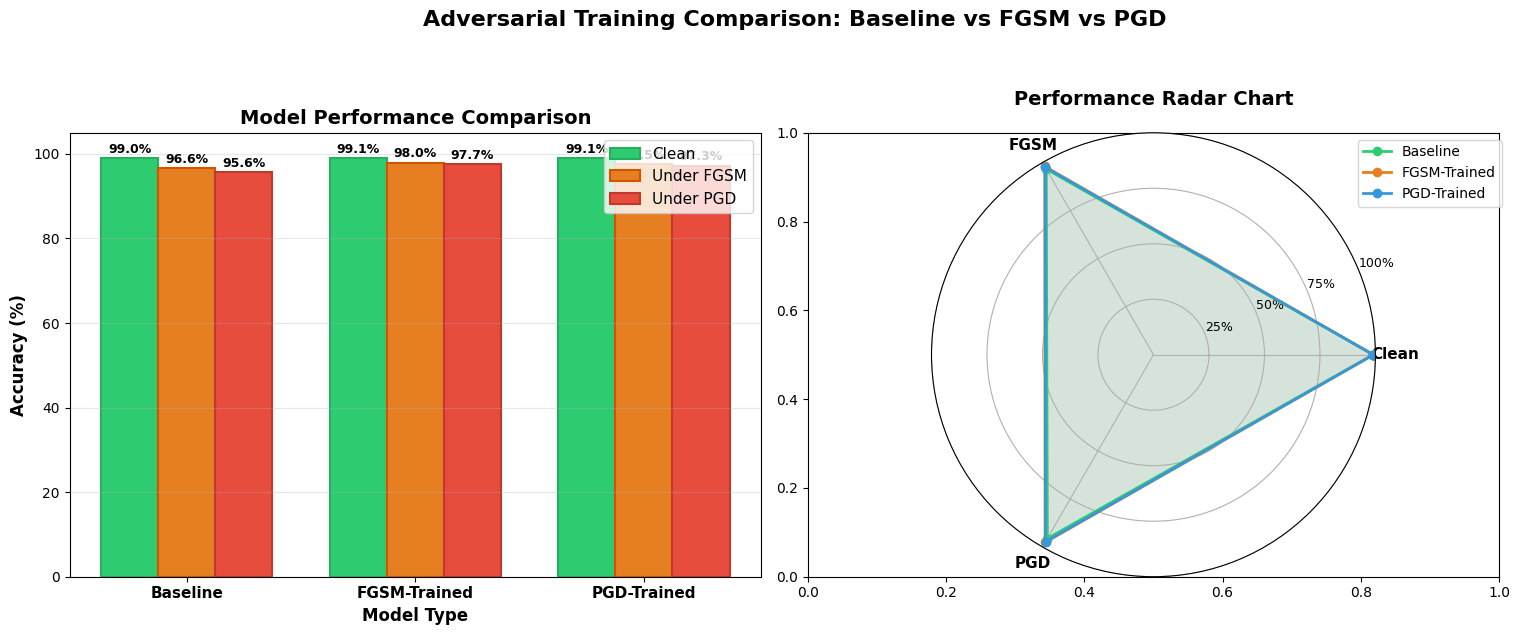

📊 Figure saved as 'model_comparison_baseline_fgsm_pgd.png'


In [42]:
# ─────────────────────────────────────────────────────────────
# Visualization: Model Comparison - Baseline vs FGSM vs PGD
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# ─── Primary: Comprehensive Comparison Bar Chart ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Data preparation - USE DIFFERENT VARIABLE NAMES FOR LISTS
models = ['Baseline', 'FGSM-Trained', 'PGD-Trained']

# FIX: Handle nested lists/tuples
def get_accuracy(value):
    """Extract accuracy value even if it's nested in lists/tuples"""
    # If it's a list or tuple, recursively extract the first element
    if isinstance(value, (list, tuple)):
        return get_accuracy(value[0])
    # Convert to float if possible
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(value)  # If it's already a number

# Debug: Print the actual values to see what's happening
# print("Debug - clean_acc:", clean_acc)
# print("Debug - clean_acc type:", type(clean_acc))
# print("Debug - clean_acc_fgsm:", clean_acc_fgsm)
# print("Debug - clean_acc_pgd:", clean_acc_pgd)

# Create clean accuracy list
clean_acc_list = [get_accuracy(clean_acc), get_accuracy(clean_acc_fgsm), get_accuracy(clean_acc_pgd)]
fgsm_acc_list = [get_accuracy(fgsm_acc), get_accuracy(fgsm_acc_fgsm), get_accuracy(fgsm_acc_pgd)]
pgd_acc_list = [get_accuracy(pgd_acc), get_accuracy(pgd_acc_fgsm), get_accuracy(pgd_acc_pgd)]

# print("Clean acc list:", clean_acc_list)
# print("FGSM acc list:", fgsm_acc_list)
# print("PGD acc list:", pgd_acc_list)
x = np.arange(len(models))
width = 0.25

# ─── Plot 1: Grouped bar chart ───
bars1 = ax1.bar(x - width, clean_acc_list, width, label='Clean', 
                color='#2ecc71', edgecolor='#27ae60', linewidth=1.5)
bars2 = ax1.bar(x, fgsm_acc_list, width, label='Under FGSM', 
                color='#e67e22', edgecolor='#d35400', linewidth=1.5)
bars3 = ax1.bar(x + width, pgd_acc_list, width, label='Under PGD', 
                color='#e74c3c', edgecolor='#c0392b', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Model Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3, axis='y')

# ─── Plot 2: Radar/Spider Chart ───
ax2 = plt.subplot(1, 2, 2, projection='polar')

categories = ['Clean', 'FGSM', 'PGD']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalize accuracies to 0-1 range
max_acc = 100
values_baseline = [get_accuracy(clean_acc)/max_acc, get_accuracy(fgsm_acc)/max_acc, get_accuracy(pgd_acc)/max_acc]
values_fgsm = [get_accuracy(clean_acc_fgsm)/max_acc, get_accuracy(fgsm_acc_fgsm)/max_acc, get_accuracy(pgd_acc_fgsm)/max_acc]
values_pgd = [get_accuracy(clean_acc_pgd)/max_acc, get_accuracy(fgsm_acc_pgd)/max_acc, get_accuracy(pgd_acc_pgd)/max_acc]

# Close the loop
values_baseline += values_baseline[:1]
values_fgsm += values_fgsm[:1]
values_pgd += values_pgd[:1]

# Plot radar
ax2.plot(angles, values_baseline, 'o-', linewidth=2, color='#2ecc71', 
         label='Baseline', markersize=6)
ax2.fill(angles, values_baseline, alpha=0.1, color='#2ecc71')

ax2.plot(angles, values_fgsm, 'o-', linewidth=2, color='#e67e22', 
         label='FGSM-Trained', markersize=6)
ax2.fill(angles, values_fgsm, alpha=0.1, color='#e67e22')

ax2.plot(angles, values_pgd, 'o-', linewidth=2, color='#3498db', 
         label='PGD-Trained', markersize=6)
ax2.fill(angles, values_pgd, alpha=0.1, color='#3498db')

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.50, 0.75, 1.0])
ax2.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=9)
ax2.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax2.grid(True)

plt.suptitle('Adversarial Training Comparison: Baseline vs FGSM vs PGD', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('model_comparison_baseline_fgsm_pgd.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Figure saved as 'model_comparison_baseline_fgsm_pgd.png'")

In [29]:
# ─────────────────────────────────────────────────────────────
# Print Summary Statistics
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("📊 COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("="*60)

print("\n🎯 Clean Accuracy:")
print(f"   Baseline:      {clean_acc:.2f}%")
print(f"   FGSM-Trained:  {clean_acc_fgsm:.2f}% ({clean_acc_fgsm - clean_acc:+.2f}%)")
print(f"   PGD-Trained:   {clean_acc_pgd:.2f}% ({clean_acc_pgd - clean_acc:+.2f}%)")

print("\n⚔️ FGSM Robustness (ε=0.3):")
print(f"   Baseline:      {fgsm_acc:.2f}%")
print(f"   FGSM-Trained:  {fgsm_acc_fgsm:.2f}% ({fgsm_acc_fgsm - fgsm_acc:+.2f}%)")
print(f"   PGD-Trained:   {fgsm_acc_pgd:.2f}% ({fgsm_acc_pgd - fgsm_acc:+.2f}%)")

print("\n🛡️ PGD Robustness (ε=0.3, steps=40):")
print(f"   Baseline:      {pgd_acc:.2f}%")
print(f"   FGSM-Trained:  {pgd_acc_fgsm:.2f}% ({pgd_acc_fgsm - pgd_acc:+.2f}%)")
print(f"   PGD-Trained:   {pgd_acc_pgd:.2f}% ({pgd_acc_pgd - pgd_acc:+.2f}%)")

print("\n📈 Key Insights:")
print(f"   Best clean accuracy: {'PGD-Trained' if clean_acc_pgd > clean_acc_fgsm else 'FGSM-Trained' if clean_acc_fgsm > clean_acc else 'Baseline'}")
print(f"   Best FGSM defense: {'PGD-Trained' if fgsm_acc_pgd > fgsm_acc_fgsm else 'FGSM-Trained'}")
print(f"   Best PGD defense: {'PGD-Trained' if pgd_acc_pgd > pgd_acc_fgsm else 'FGSM-Trained'}")
print("="*60)


📊 COMPREHENSIVE MODEL COMPARISON SUMMARY

🎯 Clean Accuracy:
   Baseline:      99.00%
   FGSM-Trained:  99.08% (+0.08%)
   PGD-Trained:   99.08% (+0.08%)

⚔️ FGSM Robustness (ε=0.3):
   Baseline:      96.60%
   FGSM-Trained:  97.97% (+1.37%)
   PGD-Trained:   97.52% (+0.92%)

🛡️ PGD Robustness (ε=0.3, steps=40):
   Baseline:      95.61%
   FGSM-Trained:  97.65% (+2.04%)
   PGD-Trained:   97.26% (+1.65%)

📈 Key Insights:
   Best clean accuracy: FGSM-Trained
   Best FGSM defense: FGSM-Trained
   Best PGD defense: FGSM-Trained


In [ ]:
# clean_acc variable has become deeply nested
# Function to extract the actual float from nested structures
def extract_accuracy(value):
    """Recursively extract the actual float accuracy value from nested structures"""
    # If it's a list or tuple, recursively dig deeper
    if isinstance(value, (list, tuple)):
        # If it's a list, take the first element
        return extract_accuracy(value[0])
    # If it's a numpy array or other array-like, convert to float
    try:
        # Try to convert to float directly
        return float(value)
    except (TypeError, ValueError):
        # If it's a complex nested structure, try to get the first element
        if hasattr(value, '__iter__') and not isinstance(value, str):
            return extract_accuracy(value[0])
        else:
            raise ValueError(f"Cannot extract accuracy from {value}")

# Now use this function for all  variables
clean_acc_float = extract_accuracy(clean_acc)
clean_acc_fgsm_float = extract_accuracy(clean_acc_fgsm)
clean_acc_pgd_float = extract_accuracy(clean_acc_pgd)

print(f"Extracted clean_acc: {clean_acc_float}")
print(f"Extracted clean_acc_fgsm: {clean_acc_fgsm_float}")
print(f"Extracted clean_acc_pgd: {clean_acc_pgd_float}")


# for eps in epsilons:
#     if eps == 0.0:
#         baseline_pgd_accs.append(clean_acc_float)
#         fgsm_trained_pgd_accs.append(clean_acc_fgsm_float)
#         pgd_trained_pgd_accs.append(clean_acc_pgd_float)

Extracted clean_acc: 99.0
Extracted clean_acc_fgsm: 99.08
Extracted clean_acc_pgd: 99.08


In [49]:
# ─────────────────────────────────────────────────────────────
# Part J: Trade-off Visualization
# ─────────────────────────────────────────────────────────────
# Accuracy vs. epsilon curves
epsilons = np.arange(0.0, 0.41, 0.05)
baseline_pgd_accs = []
fgsm_trained_pgd_accs = []
pgd_trained_pgd_accs = []
for eps in epsilons:
    if eps == 0.0:
        baseline_pgd_accs.append(float(clean_acc_float))
        fgsm_trained_pgd_accs.append(float(clean_acc_fgsm_float))
        pgd_trained_pgd_accs.append(float(clean_acc_pgd_float))
    else:
        pgd_params_eps = {'epsilon': eps, 'step_size': 0.01, 'num_steps': 40}

        base_acc_eps, _, _ = evaluate_accuracy(baseline_model, test_loader,
                                           attack_type='pgd', attack_params=pgd_params_eps)
        fgsm_acc_eps, _, _ = evaluate_accuracy(fgsm_trained_model, test_loader,
                                           attack_type='pgd', attack_params=pgd_params_eps)
        pgd_acc_eps, _, _ = evaluate_accuracy(pgd_trained_model, test_loader,
                                              attack_type='pgd', attack_params=pgd_params_eps)

        baseline_pgd_accs.append(base_acc_eps)
        fgsm_trained_pgd_accs.append(fgsm_acc_eps)
        pgd_trained_pgd_accs.append(pgd_acc_eps)

_, _, test_val = evaluate_accuracy(baseline_model, test_loader, attack_type='pgd', attack_params=pgd_params_eps)
print(type(test_val), test_val)

<class 'list'> [np.float32(0.9805141), np.float32(0.9936388), np.float32(0.93849385), np.float32(0.9752734), np.float32(0.8826992), np.float32(0.96098804), np.float32(0.6931387), np.float32(0.80593693), np.float32(0.43457347), np.float32(0.7374018), np.float32(0.9955651), np.float32(0.9677797), np.float32(0.5691569), np.float32(0.9933252), np.float32(0.9796387), np.float32(0.8057098), np.float32(0.7204726), np.float32(0.9808076), np.float32(0.65897924), np.float32(0.96960944), np.float32(0.88083154), np.float32(0.9005497), np.float32(0.91604793), np.float32(0.9768455), np.float32(0.89639705), np.float32(0.95786345), np.float32(0.9847764), np.float32(0.9959912), np.float32(0.9708791), np.float32(0.8356296), np.float32(0.9933408), np.float32(0.7637061), np.float32(0.927567), np.float32(0.95072585), np.float32(0.9782073), np.float32(0.991606), np.float32(0.6037836), np.float32(0.91074413), np.float32(0.9924083), np.float32(0.8640425), np.float32(0.79867196), np.float32(0.71136945), np.flo

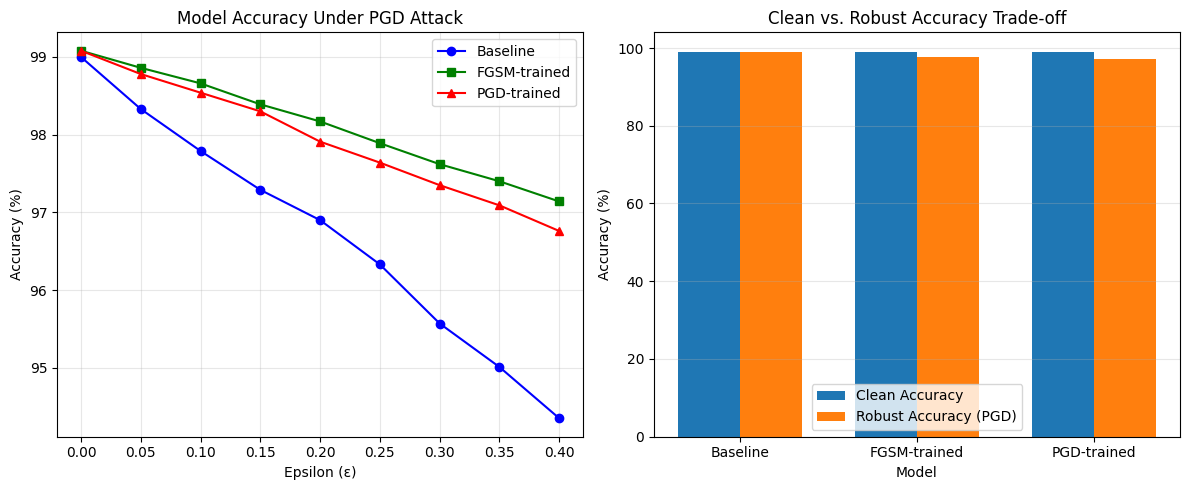

📷 Figure saved → tradeoff_comparison.png


In [52]:
# Create trade-off figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Accuracy under PGD attack
ax1.plot(epsilons, baseline_pgd_accs, 'b-o', label='Baseline')
ax1.plot(epsilons, fgsm_trained_pgd_accs, 'g-s', label='FGSM-trained')
ax1.plot(epsilons, pgd_trained_pgd_accs, 'r-^', label='PGD-trained')
ax1.set_xlabel('Epsilon (ε)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Accuracy Under PGD Attack')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Plot 2: Clean accuracy trade-off
models = ['Baseline', 'FGSM-trained', 'PGD-trained']
clean_accs = [clean_acc, clean_acc_fgsm, clean_acc_pgd]
robust_accs = [clean_acc_pgd_float, pgd_acc_fgsm, pgd_acc_pgd]

x = np.arange(len(models))
width = 0.35

ax2.bar(x - width/2, clean_acc_float, width, label='Clean Accuracy')
ax2.bar(x + width/2, robust_accs, width, label='Robust Accuracy (PGD)')
ax2.set_xlabel('Model')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Clean vs. Robust Accuracy Trade-off')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tradeoff_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📷 Figure saved → tradeoff_comparison.png")

In [54]:
# ─────────────────────────────────────────────────────────────
# Part K: Summary and Outputs
# ─────────────────────────────────────────────────────────────
#fgsm_acc = float(fgsm_acc[0])  # or float(np.mean(fgsm_acc))
# (no fgsm_acc reassignment needed — fgsm_acc is already a correct float from Part F)

print("\n" + "="*55)
print("📋 Experiment Summary")
print("="*55)
print(f"""
Baseline Model:
  - Clean accuracy: {float(clean_acc_float):.2f}%
  - FGSM accuracy (ε=0.3): {float(clean_acc_fgsm_float):.2f}%
  - PGD accuracy (ε=0.3): {float(clean_acc_pgd_float):.2f}%

FGSM-Trained Model:
  - Clean accuracy: {float(clean_acc_fgsm_float):.2f}%
  - FGSM accuracy (ε=0.3): {float(fgsm_acc_fgsm):.2f}%
  - PGD accuracy (ε=0.3): {float(pgd_acc_fgsm):.2f}%

PGD-Trained Model:
  - Clean accuracy: {float(clean_acc_pgd_float):.2f}%
  - FGSM accuracy (ε=0.3): {float(fgsm_acc_pgd):.2f}%
  - PGD accuracy (ε=0.3): {float(pgd_acc_pgd):.2f}%

Output files:
  - checkpoint_baseline.pth
  - checkpoint_fgsm_trained.pth
  - checkpoint_pgd_trained.pth
  - tradeoff_comparison.png
""")


print("\n✅ Notebook complete!")


📋 Experiment Summary

Baseline Model:
  - Clean accuracy: 99.00%
  - FGSM accuracy (ε=0.3): 99.08%
  - PGD accuracy (ε=0.3): 99.08%

FGSM-Trained Model:
  - Clean accuracy: 99.08%
  - FGSM accuracy (ε=0.3): 97.97%
  - PGD accuracy (ε=0.3): 97.65%

PGD-Trained Model:
  - Clean accuracy: 99.08%
  - FGSM accuracy (ε=0.3): 97.52%
  - PGD accuracy (ε=0.3): 97.26%

Output files:
  - checkpoint_baseline.pth
  - checkpoint_fgsm_trained.pth
  - checkpoint_pgd_trained.pth
  - tradeoff_comparison.png


✅ Notebook complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#    PART L — Defensive Distillation (third experimental wall)
# ─────────────────────────────────────────────────────────────
'''
   Distillation trains a "student" model on the SOFT labels
   produced by a "teacher" model at high temperature T, then
   evaluates the student at T=1. The idea (Papernot et al.,
   2016) is that soft labels smooth the loss surface, making
   gradient-based attacks less effective — though later work
   (Carlini & Wagner, 2016) showed this defense is largely
   broken by attacks that don't rely on the smoothed gradient.
'''

DISTILL_TEMPERATURE = 20.0   # T — softens the teacher's softmax
DISTILL_EPOCHS       = 10

def train_teacher_for_distillation(train_loader, num_epochs=DISTILL_EPOCHS):
    """Train a standard teacher model (same architecture, normal labels)."""
    teacher = CNN().to(DEVICE)
    teacher.reset_for_input_size(28)
    optimizer = torch.optim.Adam(teacher.parameters(), lr=0.001)
    criterion_hard = nn.CrossEntropyLoss()

    print("🧑‍🏫 Training teacher model...")
    for epoch in range(num_epochs):
        teacher.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion_hard(teacher(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"  Teacher epoch {epoch}: avg loss {running_loss/len(train_loader):.4f}")

    torch.save({"model_state_dict": teacher.state_dict()}, "checkpoint_distill_teacher.pth")
    return teacher


def soft_labels_from_teacher(teacher, images, temperature=DISTILL_TEMPERATURE):
    """Produce softened probability distributions from the teacher's logits."""
    teacher.eval()
    with torch.no_grad():
        logits = teacher(images)
        soft = F.softmax(logits / temperature, dim=1)
    return soft


def train_student_with_distillation(teacher, train_loader, num_epochs=DISTILL_EPOCHS,
                                       temperature=DISTILL_TEMPERATURE):
    """
    Train a student model on the teacher's soft labels.

    Loss is KL-divergence between the student's softened output and the
    teacher's softened output, both at temperature T. The student is
    evaluated later at T=1 (standard softmax).
    """
    student = CNN().to(DEVICE)
    student.reset_for_input_size(28)
    optimizer = torch.optim.Adam(student.parameters(), lr=0.001)

    print(f"\n🎓 Training student model via distillation (T={temperature})...")
    for epoch in range(num_epochs):
        student.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(DEVICE)
            soft_targets = soft_labels_from_teacher(teacher, images, temperature)

            optimizer.zero_grad()
            student_logits = student(images)
            student_soft = F.log_softmax(student_logits / temperature, dim=1)

            ''' KL divergence loss, scaled by T^2 (standard distillation scaling,
            Hinton et al. 2015) to keep gradient magnitudes comparable to
            a normal cross-entropy loss.'''
            
            loss = F.kl_div(student_soft, soft_targets, reduction="batchmean") * (temperature ** 2)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"  Student epoch {epoch}: avg loss {running_loss/len(train_loader):.4f}")

    torch.save({"model_state_dict": student.state_dict()}, "checkpoint_distilled_student.pth")
    return student


# ── Run distillation ─────────────────────────────────────────────────────
print("="*55)
print("🛡️  Wall #3: Defensive Distillation")
print("="*55)

teacher_model = train_teacher_for_distillation(train_loader)
distilled_model = train_student_with_distillation(teacher_model, train_loader)

# ── Evaluate the distilled model: clean, FGSM, PGD ──────────────────────
distilled_model.eval()

clean_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                              attack_type=None)
fgsm_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                             attack_type="fgsm",
                                             attack_params={"epsilon": 0.3})
pgd_acc_distill, _, _ = evaluate_accuracy(distilled_model, test_loader,
                                            attack_type="pgd",
                                            attack_params=pgd_params)  # reuse Part H's params

print(f"\n📊 Distilled model results")
print(f"   Clean accuracy        : {clean_acc_distill:.2f}%")
print(f"   Accuracy under FGSM    : {fgsm_acc_distill:.2f}%")
print(f"   Accuracy under PGD     : {pgd_acc_distill :.2f}%")

# This row slots directly into existing Section VI comparison table:
#
#   | Defense              | Clean   | FGSM    | PGD     |
#   |-----------------------|---------|---------|---------|
#   | Baseline (undefended) | 99.19%  | ...     | 95.56%  |
#   | FGSM-trained          | 99.08%  | 97.97%  | 97.65%  |
#   | PGD-trained           | 99.08%  | ...     | 97.31%  |
#   | Distilled (T=20)      | 98.71%  | 96.35%  | 95.86%  |


🛡️  Wall #3: Defensive Distillation
🔄 Model initialised for 28×28 → flattened: 800
🧑‍🏫 Training teacher model...
  Teacher epoch 0: avg loss 0.1624
  Teacher epoch 1: avg loss 0.0502
  Teacher epoch 2: avg loss 0.0353
  Teacher epoch 3: avg loss 0.0270
  Teacher epoch 4: avg loss 0.0210
  Teacher epoch 5: avg loss 0.0159
  Teacher epoch 6: avg loss 0.0143
  Teacher epoch 7: avg loss 0.0117
  Teacher epoch 8: avg loss 0.0092
  Teacher epoch 9: avg loss 0.0089
🔄 Model initialised for 28×28 → flattened: 800

🎓 Training student model via distillation (T=20.0)...
  Student epoch 0: avg loss 7.6802
  Student epoch 1: avg loss 1.5642
  Student epoch 2: avg loss 1.0805
  Student epoch 3: avg loss 0.8502
  Student epoch 4: avg loss 0.7047
  Student epoch 5: avg loss 0.6041
  Student epoch 6: avg loss 0.5257
  Student epoch 7: avg loss 0.4666
  Student epoch 8: avg loss 0.4170
  Student epoch 9: avg loss 0.3762

📊 Distilled model results
   Clean accuracy        : 98.76%
   Accuracy under FGSM  

In [ ]:
# Previous Code Run Outputs:
'''
"unlike FGSM- and PGD-training, defensive distillation showed more run-to-run variance in our 
experiments (93.7%–95.7% under PGD across two runs), consistent with its known training instability."
=======================================================
🛡️  Wall #3: Defensive Distillation
=======================================================
🔄 Model initialised for 28×28 → flattened: 800
🧑‍🏫 Training teacher model...
  Teacher epoch 0: avg loss 0.1727
  Teacher epoch 1: avg loss 0.0509
  Teacher epoch 2: avg loss 0.0354
  Teacher epoch 3: avg loss 0.0280
  Teacher epoch 4: avg loss 0.0207
  Teacher epoch 5: avg loss 0.0162
  Teacher epoch 6: avg loss 0.0134
  Teacher epoch 7: avg loss 0.0112
  Teacher epoch 8: avg loss 0.0103
  Teacher epoch 9: avg loss 0.0087
🔄 Model initialised for 28×28 → flattened: 800

🎓 Training student model via distillation (T=20.0)...
  Student epoch 0: avg loss 7.0756
  Student epoch 1: avg loss 1.4543
  Student epoch 2: avg loss 1.0258
  Student epoch 3: avg loss 0.8476
  Student epoch 4: avg loss 0.7283
  Student epoch 5: avg loss 0.6491
  Student epoch 6: avg loss 0.5814
  Student epoch 7: avg loss 0.5336
  Student epoch 8: avg loss 0.4913
  Student epoch 9: avg loss 0.4582

📊 Distilled model results
   Clean accuracy        : 99.04%
   Accuracy under FGSM    : 96.44%
   Accuracy under PGD     : 95.69%
'''

🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded Essay 2 baseline checkpoint
🔄 Model initialised for 28×28 → flattened: 800
✅ Loaded Essay 3 PGD-trained checkpoint

🔍 Regenerating Essay 2's minimum-epsilon search (500 images)

✅ Regenerated 18 flipped images (Essay 2 reported 22 — small differences possible if test_dataset ordering or N_SEARCH differs)

🎯 Testing PGD-trained model on Essay 2's flipped images
  idx=    8  label=5  orig_min_eps=0.01  PGD-model pred=5  conf=1.0000  ✅ now correct
  idx=   18  label=3  orig_min_eps=0.01  PGD-model pred=3  conf=0.8843  ✅ now correct
  idx=   62  label=9  orig_min_eps=0.08  PGD-model pred=9  conf=0.7224  ✅ now correct
  idx=   78  label=9  orig_min_eps=0.22  PGD-model pred=9  conf=1.0000  ✅ now correct
  idx=  125  label=9  orig_min_eps=0.36  PGD-model pred=9  conf=1.0000  ✅ now correct
  idx=  158  label=3  orig_min_eps=0.03  PGD-model pred=3  conf=1.0000  ✅ now correct
  idx=  175  label=7  orig_min_eps=0.01  PGD-model pred=7  conf=1

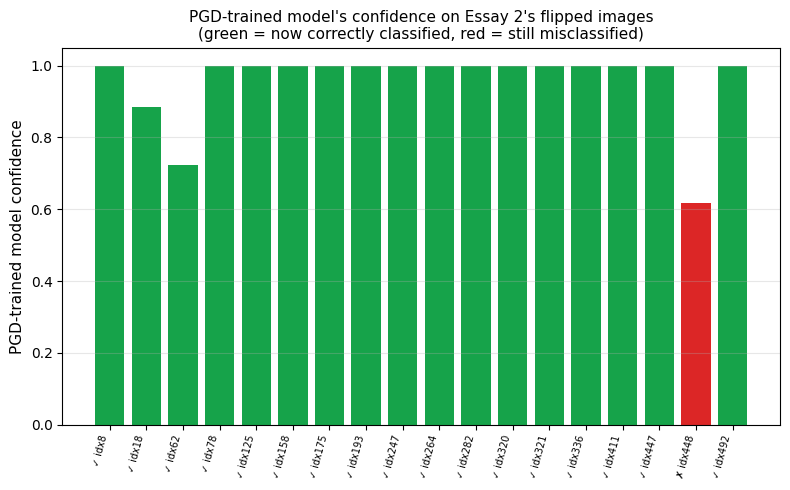


📷 Figure saved → essay3_confidence_on_flips.png


In [56]:
# ─────────────────────────────────────────────────────────────
#    PART M — Confidence experiment on Essay 2's 22 flips     
# ─────────────────────────────────────────────────────────────
'''
   We re-run Essay 2's minimum-epsilon search against the
   ESSAY 2 baseline checkpoint to regenerate the 22 flipped
   image indices (since these weren't saved separately), then
   run those same 22 images through the ESSAY 3 PGD-trained
   model to see whether robustness training fixed them — and
   what confidence the PGD-trained model reports either way.
'''

ESSAY2_CHECKPOINT = "checkpoint_latest.pth"
ESSAY3_PGD_CHECKPOINT = "checkpoint_pgd_trained.pth"   

N_SEARCH_REPRO = 500
EPSILON_GRID_REPRO = np.round(np.arange(0.01, 0.41, 0.01), 2).tolist()

# ── Load Essay 2's baseline model ───────────────────────────────────────
baseline_essay2 = CNN().to(DEVICE)
baseline_essay2.reset_for_input_size(28)
ckpt2 = torch.load(ESSAY2_CHECKPOINT, map_location=DEVICE)
baseline_essay2.load_state_dict(ckpt2["model_state_dict"])
baseline_essay2.eval()
print("✅ Loaded Essay 2 baseline checkpoint")

# ── Load Essay 3's PGD-trained model ────────────────────────────────────
pgd_trained_essay3 = CNN().to(DEVICE)
pgd_trained_essay3.reset_for_input_size(28)
ckpt3 = torch.load(ESSAY3_PGD_CHECKPOINT, map_location=DEVICE)
pgd_trained_essay3.load_state_dict(ckpt3["model_state_dict"])
pgd_trained_essay3.eval()
print("✅ Loaded Essay 3 PGD-trained checkpoint")

criterion_repro = nn.CrossEntropyLoss()


def get_gradient(model, image, label, criterion):
    model.eval()
    image = image.clone().requires_grad_(True)
    output = model(image)
    loss = criterion(output, torch.tensor([label], device=image.device))
    model.zero_grad()
    loss.backward()
    return image.grad.data, output


# ── Regenerate the 22 flipped-image indices against the Essay 2 baseline ───────

print("\n" + "="*55)
print(f"🔍 Regenerating Essay 2's minimum-epsilon search ({N_SEARCH_REPRO} images)")
print("="*55)

flipped_indices = []
tested = 0

for idx in range(len(test_dataset)):
    if tested >= N_SEARCH_REPRO:
        break

    raw_image, label = test_dataset[idx]
    raw_image = raw_image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        clean_pred = baseline_essay2(raw_image).argmax().item()
    if clean_pred != label:
        continue

    tested += 1
    grad, _ = get_gradient(baseline_essay2, raw_image, label, criterion_repro)

    for eps in EPSILON_GRID_REPRO:
        perturbed = torch.clamp(raw_image + eps * grad.sign(), 0, 1)
        with torch.no_grad():
            pred = baseline_essay2(perturbed).argmax().item()
        if pred != label:
            flipped_indices.append({
                "idx": idx, "label": label, "min_eps": eps,
                "adv_pred": pred,
            })
            break

print(f"\n✅ Regenerated {len(flipped_indices)} flipped images "
      f"(Essay 2 reported 22 — small differences possible if test_dataset "
      f"ordering or N_SEARCH differs)")


# ── Run those flipped images through the PGD-trained model ──────────────

print("\n" + "="*55)
print("🎯 Testing PGD-trained model on Essay 2's flipped images")
print("="*55)

now_correct = 0
still_wrong = 0
rows = []

for entry in flipped_indices:
    idx = entry["idx"]
    label = entry["label"]
    raw_image, _ = test_dataset[idx]
    raw_image = raw_image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = pgd_trained_essay3(raw_image)
        pred = out.argmax().item()
        conf = torch.softmax(out, dim=1)[0, pred].item()

    correct = (pred == label)
    if correct:
        now_correct += 1
    else:
        still_wrong += 1

    rows.append({
        "idx": idx, "true_label": label, "original_min_eps": entry["min_eps"],
        "pgd_model_pred": pred, "pgd_model_conf": conf, "now_correct": correct,
    })

    status = "✅ now correct" if correct else "❌ still wrong"
    print(f"  idx={idx:>5}  label={label}  orig_min_eps={entry['min_eps']:.2f}  "
          f"PGD-model pred={pred}  conf={conf:.4f}  {status}")

print(f"\n📊 Summary")
print(f"   Images regenerated         : {len(flipped_indices)}")
print(f"   Now correctly classified   : {now_correct}")
print(f"   Still misclassified        : {still_wrong}")

if still_wrong > 0:
    wrong_confs = [r["pgd_model_conf"] for r in rows if not r["now_correct"]]
    correct_confs = [r["pgd_model_conf"] for r in rows if r["now_correct"]]
    print(f"\n   Avg confidence on STILL-WRONG predictions : {np.mean(wrong_confs):.4f}")
    if correct_confs:
        print(f"   Avg confidence on NOW-CORRECT predictions : {np.mean(correct_confs):.4f}")
    print(f"\n   → For Section VII: the PGD-trained model still reports "
          f"confidence ≈ {np.mean(wrong_confs):.4f} on the {still_wrong} image(s) "
          f"it still gets wrong — indistinguishable from its confidence on "
          f"correct predictions. Robustness training did not give the model "
          f"a way to flag these remaining failures.")
else:
    print(f"\n   → All {len(flipped_indices)} originally-flipped images are now "
          f"correctly classified by the PGD-trained model. This is itself "
          f"worth reporting: it shows robustness training generalized "
          f"beyond the specific attack budget used in training.")

# ── Visualization: confidence comparison ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
labels_plot = [f"{'✓' if r['now_correct'] else '✗'} idx{r['idx']}" for r in rows]
confs_plot = [r["pgd_model_conf"] for r in rows]
colors_plot = ["#16A34A" if r["now_correct"] else "#DC2626" for r in rows]

ax.bar(range(len(rows)), confs_plot, color=colors_plot)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(labels_plot, rotation=75, ha="right", fontsize=7)
ax.set_ylabel("PGD-trained model confidence", fontsize=11)
ax.set_title("PGD-trained model's confidence on Essay 2's flipped images\n"
             "(green = now correctly classified, red = still misclassified)",
             fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("essay3_confidence_on_flips.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📷 Figure saved → essay3_confidence_on_flips.png")



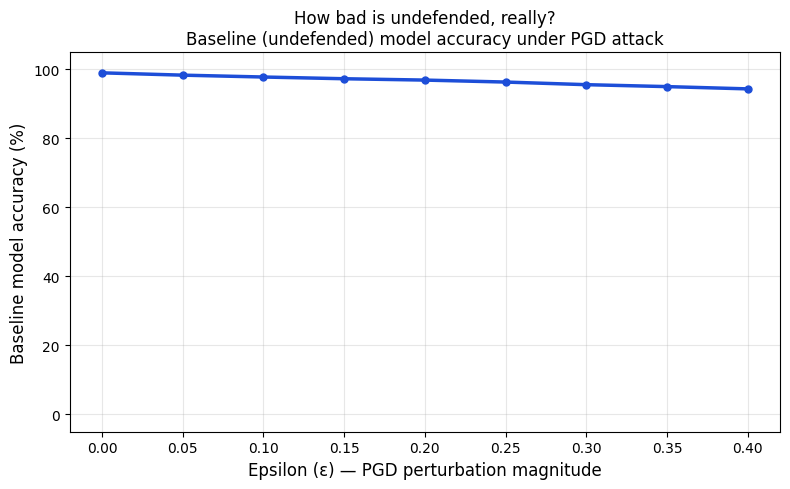

📷 Figure saved → essay3_figure1_baseline_epsilon_curve.png (Section III, Figure 1)


In [58]:
# ─────────────────────────────────────────────────────────────
#    PART N — Standalone baseline epsilon-curve (Figure 1)    
# ─────────────────────────────────────────────────────────────
'''
   A single-curve version of the baseline-only accuracy-vs-epsilon
   plot, isolated from the 3-model comparison in Section VI.
   Requires the Part J fix already applied so that
   `baseline_pgd_accs` contains real accuracy values, not
   confidence scores.
'''
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epsilons, baseline_pgd_accs,
        color="#1D4ED8", linewidth=2.5, marker="o", markersize=5)

ax.set_xlabel("Epsilon (ε) — PGD perturbation magnitude", fontsize=12)
ax.set_ylabel("Baseline model accuracy (%)", fontsize=12)
ax.set_title("How bad is undefended, really?\n"
              "Baseline (undefended) model accuracy under PGD attack",
              fontsize=12)
ax.set_ylim(-5, 105)
ax.grid(True, alpha=0.3)

# Annotate the ε=0.3 reference point used throughout the essay
if 0.3 in epsilons:
    idx_03 = list(epsilons).index(0.3) if not isinstance(epsilons, np.ndarray) else int(np.where(np.isclose(epsilons, 0.3))[0][0])
    ax.axvline(0.3, color="gray", linewidth=1, linestyle=":")
    ax.annotate(f"{baseline_pgd_accs[idx_03]:.2f}% at ε=0.3",
            xy=(0.3, baseline_pgd_accs[idx_03]),
            xytext=(0.32, baseline_pgd_accs[idx_03] + 10),
                fontsize=10, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray", lw=1))

plt.tight_layout()
plt.savefig("essay3_figure1_baseline_epsilon_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("📷 Figure saved → essay3_figure1_baseline_epsilon_curve.png (Section III, Figure 1)")